In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Muat dataset iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Identifikasi jumlah data
print("Jumlah data:", df.shape[0])

# Identifikasi tipe data
print("\nTipe data:")
print(df.dtypes)

# Identifikasi nilai yang hilang
print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())

# Identifikasi outlier (menggunakan IQR)
for column in df.columns[:-1]:  # Loop melalui fitur numerik
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  print(f"\nOutlier pada kolom {column}:")
  print(outliers)

# Deskripsi statistik data
print("\nDeskripsi statistik:")
print(df.describe())

Jumlah data: 150

Tipe data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Jumlah nilai yang hilang:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Outlier pada kolom sepal length (cm):
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []

Outlier pada kolom sepal width (cm):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

    target  
15       0  
32       0  
33       0  
60       

In [2]:
import pandas as pd
from sklearn.datasets import load_iris


# Muat dataset iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Identifikasi jumlah data
print("Jumlah data:", df.shape[0])

# Identifikasi tipe data
print("\nTipe data:")
print(df.dtypes)

# Identifikasi nilai yang hilang
print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())

# Identifikasi outlier (menggunakan IQR)
for column in df.columns[:-1]:  # Loop melalui fitur numerik
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
  print(f"\nOutlier pada kolom {column}:")
  print(outliers)

# Deskripsi statistik data
print("\nDeskripsi statistik:")
print(df.describe())


# Pembersihan data
# 1. Pengisian nilai yang hilang (jika ada)
# Dalam dataset iris, tidak ada nilai yang hilang, jadi bagian ini bisa dilewati.
# Namun, jika ada, Anda bisa menggunakan:
# df['sepal length (cm)'].fillna(df['sepal length (cm)'].mean(), inplace=True)
# df['sepal width (cm)'].fillna(df['sepal width (cm)'].median(), inplace=True)
# df['petal length (cm)'].fillna(df['petal length (cm)'].mode()[0], inplace=True)

# 2. Menghapus baris dengan data yang salah (jika ada)
# Dalam dataset iris, tidak ada data yang salah secara jelas.
# Namun, jika ada, Anda bisa menggunakan:
# df.drop(df[df['sepal length (cm)'] < 0].index, inplace=True)

# 3. Mengoreksi nilai outlier
for column in df.columns[:-1]:
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df[column] = df[column].clip(lower_bound, upper_bound)

# Setelah pembersihan data
print("\nDeskripsi statistik setelah pembersihan:")
print(df.describe())

Jumlah data: 150

Tipe data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Jumlah nilai yang hilang:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Outlier pada kolom sepal length (cm):
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []

Outlier pada kolom sepal width (cm):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

    target  
15       0  
32       0  
33       0  
60       

In [3]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
# Muat dataset iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target


# 1. Normalisasi data
# Normalisasi dilakukan menggunakan MinMaxScaler untuk mengubah rentang nilai fitur menjadi 0-1.
scaler = MinMaxScaler()
numerical_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df[numerical_features] = scaler.fit_transform(df[numerical_features])
print("\nData setelah normalisasi:")
print(df.head())

# 2. Pemilihan fitur
# Menggunakan SelectKBest untuk memilih 2 fitur terbaik berdasarkan skor ANOVA F-value.
X = df.drop('target', axis=1)
y = df['target']
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("\nFitur terpilih:", selected_features)

# 3. Binning
# Binning dilakukan pada fitur 'petal length (cm)' untuk mengelompokkan data menjadi beberapa kategori.
df['petal_length_binned'] = pd.cut(df['petal length (cm)'], bins=3, labels=['rendah', 'sedang', 'tinggi'])
print("\nData setelah binning:")
print(df.head())


Data setelah normalisasi:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           0.222222          0.625000           0.067797          0.041667   
1           0.166667          0.416667           0.067797          0.041667   
2           0.111111          0.500000           0.050847          0.041667   
3           0.083333          0.458333           0.084746          0.041667   
4           0.194444          0.666667           0.067797          0.041667   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Fitur terpilih: Index(['petal length (cm)', 'petal width (cm)'], dtype='object')

Data setelah binning:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           0.222222          0.625000           0.067797          0.041667   
1           0.166667          0.416667           0.067797          0.041667   
2           0.111111          0.500000           0.050847          0.041667   
3    

In [4]:
# Identifikasi data target dan lakukan pelabelan
# Dalam dataset iris, kolom 'target' sudah mewakili label kelas (0, 1, 2).
# Namun, jika diperlukan pelabelan yang lebih spesifik berdasarkan SOP,
# kita bisa melakukan mapping label sesuai dengan kebutuhan.

# Misalnya, jika SOP menentukan bahwa:
# - target 0: Setosa
# - target 1: Versicolor
# - target 2: Virginica
# Kita bisa membuat mapping label seperti ini:

label_mapping = {
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
}

# Buat kolom baru 'target_label' yang berisi label teks
df['target_label'] = df['target'].map(label_mapping)

# Tampilkan data dengan label baru
print("\nData dengan label berdasarkan SOP:")
print(df.head())

# Import Library
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Load Dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Identifikasi Data
print("Jumlah data:", df.shape[0])

print("\nTipe data:")
print(df.dtypes)

print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())

# Identifikasi Outlier (IQR)
for column in df.columns[:-1]:  # Fitur numerik
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"\nOutlier pada kolom {column}:")
    print(outliers)

# Deskripsi Statistik Sebelum Pembersihan
print("\nDeskripsi statistik:")
print(df.describe())

# Pembersihan Data

# 1. (Opsional) Pengisian nilai yang hilang — tidak dilakukan karena data lengkap

# 2. (Opsional) Hapus data tidak logis — tidak dilakukan karena tidak ditemukan

# 3. Koreksi nilai outlier dengan clipping
for column in df.columns[:-1]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

# Deskripsi Statistik Setelah Pembersihan
print("\nDeskripsi statistik setelah pembersihan:")
print(df.describe())

# Normalisasi Data
scaler = MinMaxScaler()
numerical_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nData setelah normalisasi:")
print(df.head())

# Pemilihan Fitur (Feature Selection)
X = df.drop('target', axis=1)
y = df['target']
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("\nFitur terpilih:", selected_features)

# Binning pada 'petal length (cm)'
df['petal_length_binned'] = pd.cut(df['petal length (cm)'], bins=3, labels=['rendah', 'sedang', 'tinggi'])

print("\nData setelah binning:")
print(df.head())

# Mapping Label Target
label_mapping = {
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
}
df['target_label'] = df['target'].map(label_mapping)

print("\nData dengan label berdasarkan SOP:")
print(df.head())


Data dengan label berdasarkan SOP:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0           0.222222          0.625000           0.067797          0.041667   
1           0.166667          0.416667           0.067797          0.041667   
2           0.111111          0.500000           0.050847          0.041667   
3           0.083333          0.458333           0.084746          0.041667   
4           0.194444          0.666667           0.067797          0.041667   

   target petal_length_binned target_label  
0       0              rendah       Setosa  
1       0              rendah       Setosa  
2       0              rendah       Setosa  
3       0              rendah       Setosa  
4       0              rendah       Setosa  
Jumlah data: 150

Tipe data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Jumlah nilai yang hilang:
sepa

Jumlah data: 150

Tipe data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object

Jumlah nilai yang hilang:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Outlier pada kolom sepal length (cm):
Empty DataFrame
Columns: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm), target]
Index: []

Outlier pada kolom sepal width (cm):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
15                5.7               4.4                1.5               0.4   
32                5.2               4.1                1.5               0.1   
33                5.5               4.2                1.4               0.2   
60                5.0               2.0                3.5               1.0   

    target  
15       0  
32       0  
33       0  
60       

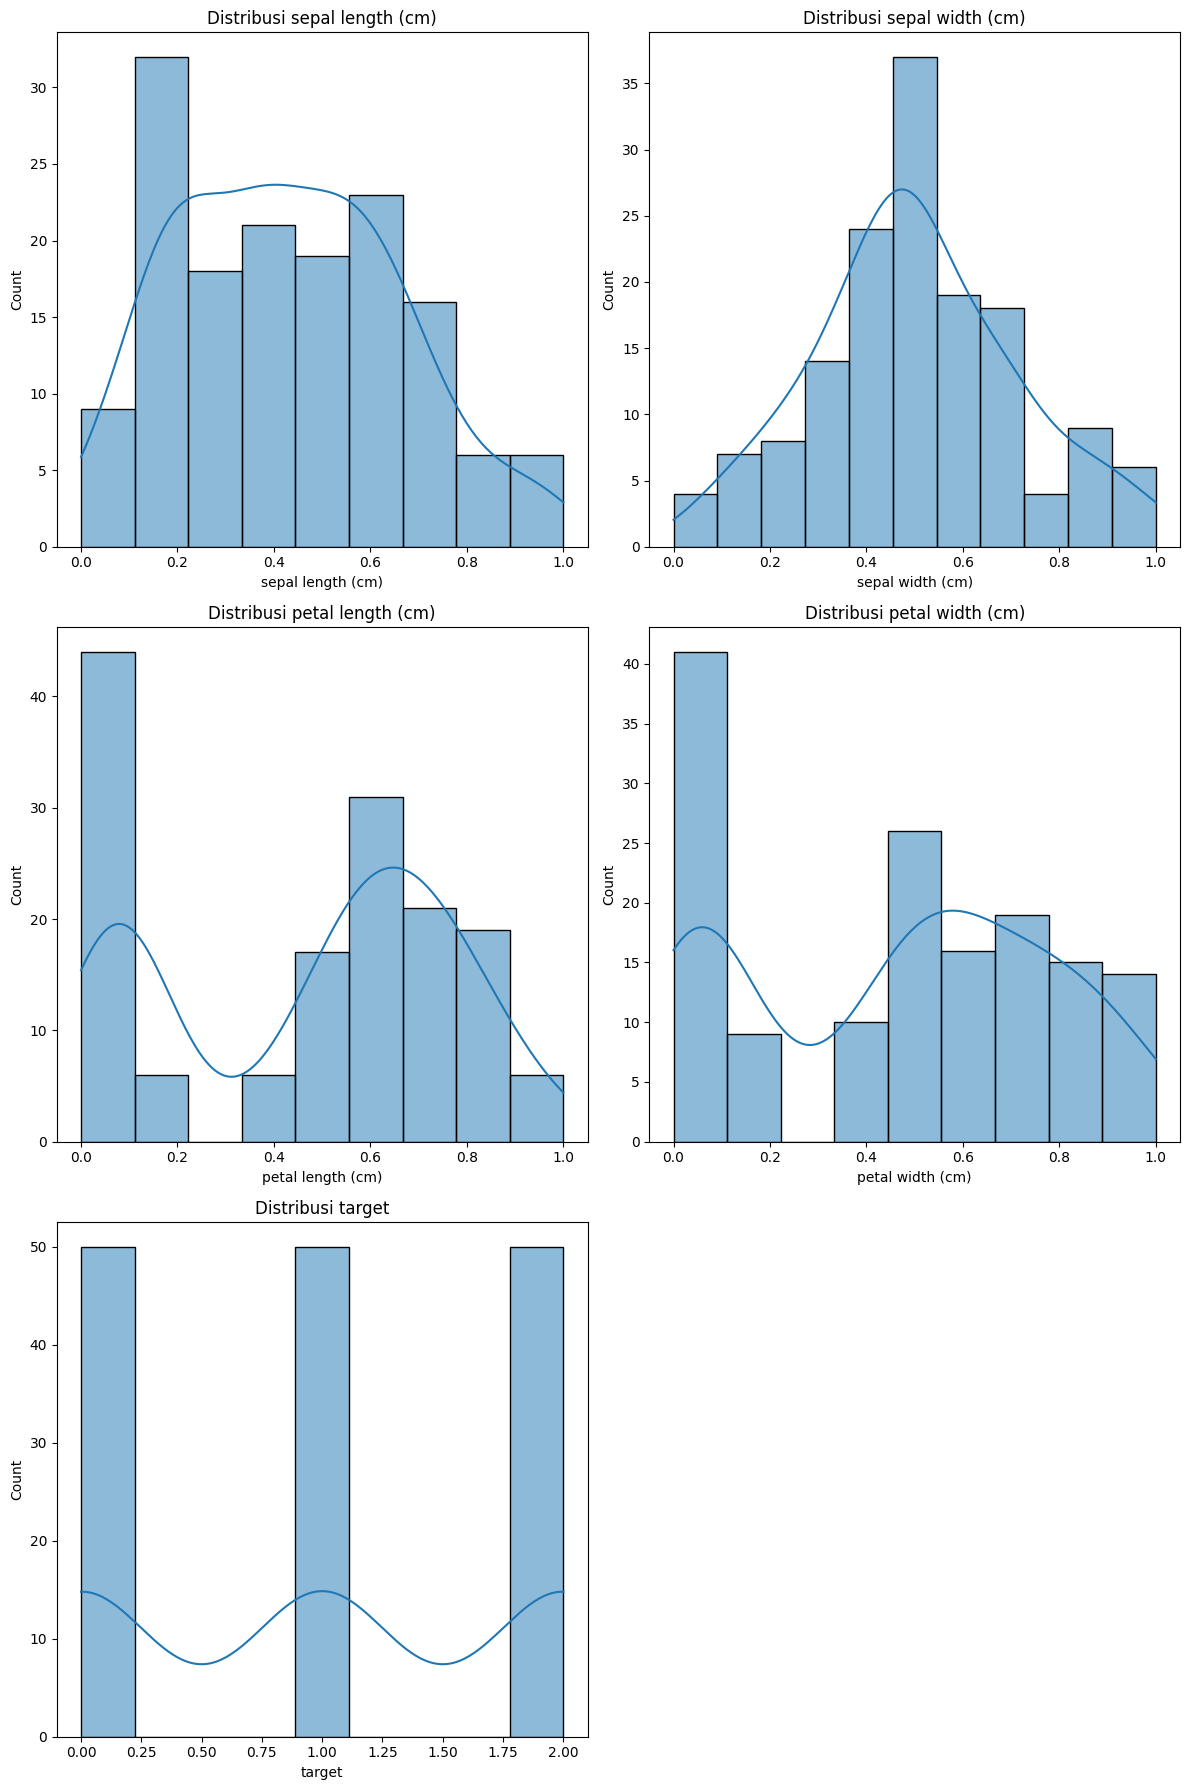

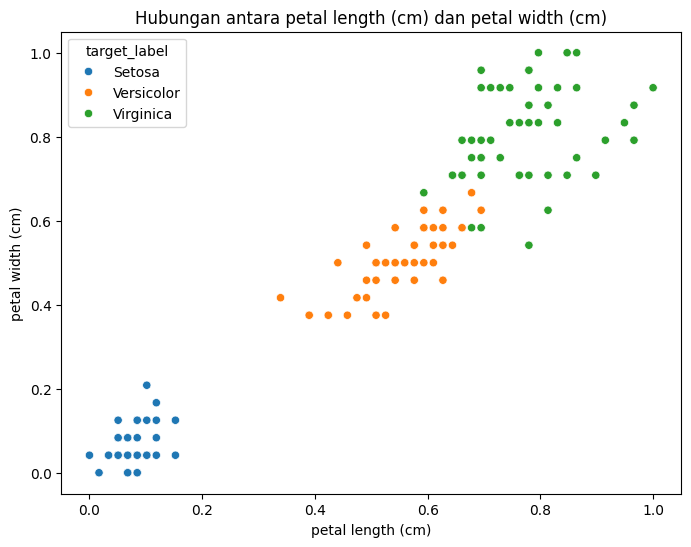

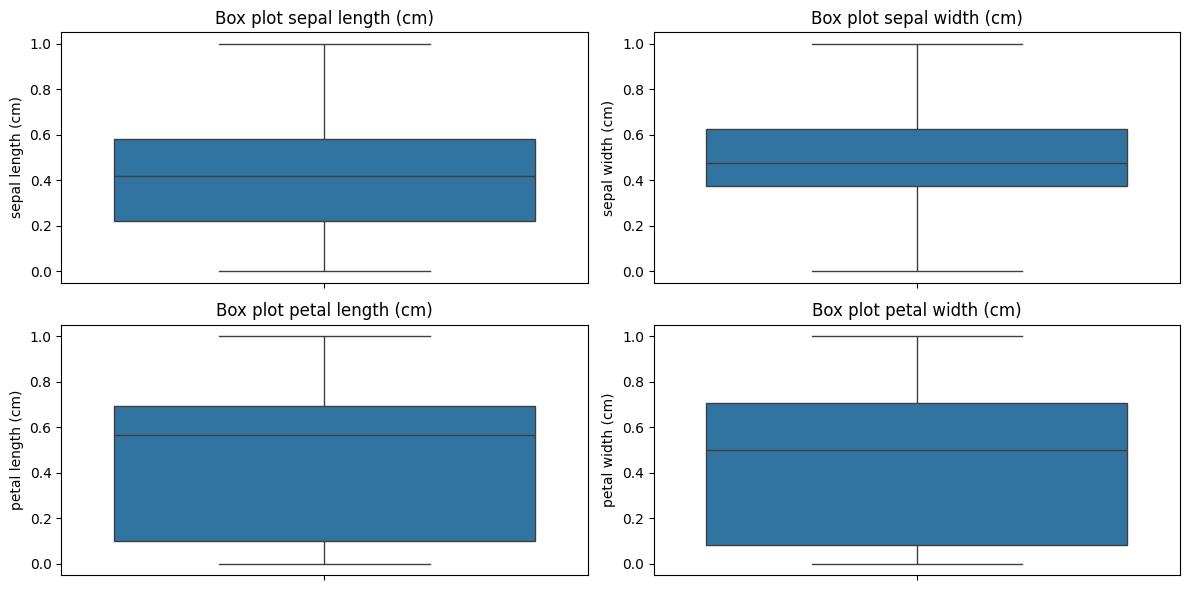

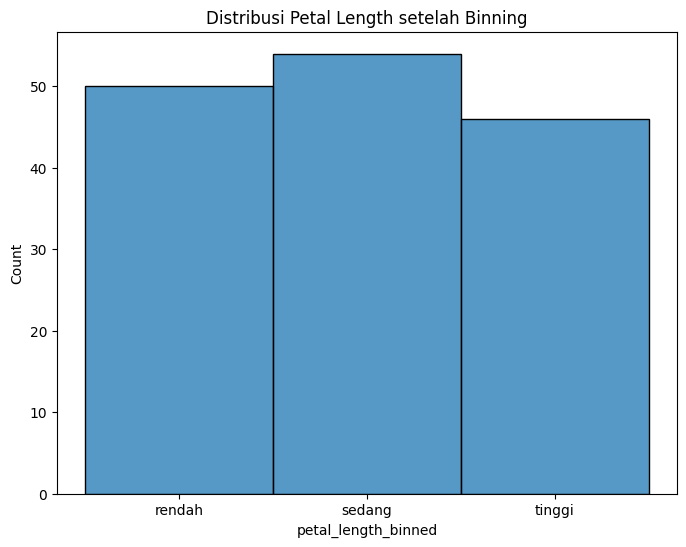

In [5]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Load Dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Identifikasi Data
print("Jumlah data:", df.shape[0])

print("\nTipe data:")
print(df.dtypes)

print("\nJumlah nilai yang hilang:")
print(df.isnull().sum())

# Identifikasi Outlier (IQR)
for column in df.columns[:-1]:  # Fitur numerik
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"\nOutlier pada kolom {column}:")
    print(outliers)

# Deskripsi Statistik Sebelum Pembersihan
print("\nDeskripsi statistik:")
print(df.describe())

# Pembersihan Data

# 1. (Opsional) Pengisian nilai yang hilang — tidak dilakukan karena data lengkap

# 2. (Opsional) Hapus data tidak logis — tidak dilakukan karena tidak ditemukan

# 3. Koreksi nilai outlier dengan clipping
for column in df.columns[:-1]:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

# Deskripsi Statistik Setelah Pembersihan
print("\nDeskripsi statistik setelah pembersihan:")
print(df.describe())

# Normalisasi Data
scaler = MinMaxScaler()
numerical_features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nData setelah normalisasi:")
print(df.head())

# Pemilihan Fitur (Feature Selection)
X = df.drop('target', axis=1)
y = df['target']
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

print("\nFitur terpilih:", selected_features)

# Binning pada 'petal length (cm)'
df['petal_length_binned'] = pd.cut(df['petal length (cm)'], bins=3, labels=['rendah', 'sedang', 'tinggi'])

print("\nData setelah binning:")
print(df.head())

# Mapping Label Target
label_mapping = {
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
}
df['target_label'] = df['target'].map(label_mapping)

print("\nData dengan label berdasarkan SOP:")
print(df.head())


# Histogram untuk melihat distribusi data setelah pembersihan
# Adjust the subplot grid to accommodate all columns
num_cols = len(df.columns[:-2])
num_rows = (num_cols + 1) // 2  # Calculate rows needed
plt.figure(figsize=(12, 6 * num_rows)) # Adjust figure height

for i, column in enumerate(df.columns[:-2]):  # Loop melalui fitur numerik
  plt.subplot(num_rows, 2, i + 1)  # Use calculated rows and cols
  sns.histplot(df[column], kde=True)
  plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

# Scatter plot untuk melihat hubungan antara dua fitur terpilih
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[selected_features[0]], y=df[selected_features[1]], hue=df['target_label'])
plt.title(f'Hubungan antara {selected_features[0]} dan {selected_features[1]}')
plt.show()

# Box plot untuk melihat distribusi data sebelum dan sesudah normalisasi
plt.figure(figsize=(12, 6))
for i, column in enumerate(numerical_features):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data=df, y=column)
  plt.title(f'Box plot {column}')
plt.tight_layout()
plt.show()

# Histogram untuk melihat distribusi data setelah binning
plt.figure(figsize=(8, 6))
sns.histplot(df['petal_length_binned'], kde=False)
plt.title('Distribusi Petal Length setelah Binning')
plt.show()

In [6]:
print("\nStatistik Deskriptif Data Setelah Pembersihan:")
print(df.describe())


Statistik Deskriptif Data Setelah Pembersihan:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            0.428704          0.502000           0.467458   
std             0.230018          0.212695           0.299203   
min             0.000000          0.000000           0.000000   
25%             0.222222          0.375000           0.101695   
50%             0.416667          0.475000           0.567797   
75%             0.583333          0.625000           0.694915   
max             1.000000          1.000000           1.000000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           0.458056    1.000000  
std            0.317599    0.819232  
min            0.000000    0.000000  
25%            0.083333    0.000000  
50%            0.500000    1.000000  
75%            0.708333    2.000000  
max            1.000000    2.000000  


In [9]:
# prompt: Dari proses sebelumnya, identifikasi parameter-parameter yang sesuai dengan model yang akan dibangun. Catat parameter tersebut beserta penjelasannya.

# Identifikasi Parameter untuk Model

print("Parameter yang mungkin relevan untuk model:")
print("- Fitur terpilih: ", selected_features)
print("  - Parameter ini digunakan sebagai input untuk model, dipilih berdasarkan skor ANOVA F-value.")
print("- Target label: 'target_label'")
print("  - Parameter ini merupakan output yang ingin diprediksi oleh model, mewakili label jenis bunga iris.")
print("- Data setelah normalisasi dan pembersihan.")
print("  - Data yang telah dibersihkan dan dinormalisasi diharapkan meningkatkan performa model.")

# Catatan:
# - Parameter-parameter lain yang mungkin relevan bergantung pada model yang akan digunakan.
# - Misalnya, jika menggunakan model pohon keputusan, parameter seperti kedalaman pohon dan jumlah daun bisa dipertimbangkan.
# - Jika menggunakan model regresi logistik, parameter seperti regularization dan learning rate bisa dipertimbangkan.
# - Selanjutnya, Anda dapat melakukan analisis lebih lanjut terkait parameter model yang paling optimal untuk dipilih berdasarkan model yang diinginkan dan dataset yang dimiliki.

Parameter yang mungkin relevan untuk model:
- Fitur terpilih:  Index(['petal length (cm)', 'petal width (cm)'], dtype='object')
  - Parameter ini digunakan sebagai input untuk model, dipilih berdasarkan skor ANOVA F-value.
- Target label: 'target_label'
  - Parameter ini merupakan output yang ingin diprediksi oleh model, mewakili label jenis bunga iris.
- Data setelah normalisasi dan pembersihan.
  - Data yang telah dibersihkan dan dinormalisasi diharapkan meningkatkan performa model.


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Pisahkan data menjadi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    df[selected_features], df['target'], test_size=0.2, random_state=42
)

# Buat model Logistic Regression
model = LogisticRegression(max_iter=1000)  # Menentukan jumlah iterasi maksimum

# Latih model dengan data training
model.fit(X_train, y_train)

# Lakukan prediksi dengan data testing
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi model: {accuracy}")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# Catatan hasil eksekusi dan parameter model
print("\nHasil Eksekusi:")
print(f"- Algoritma yang digunakan: Logistic Regression")
print(f"- Fitur yang digunakan: {selected_features}")
print(f"- Akurasi model: {accuracy}")
print(f"- Parameter model: max_iter={model.max_iter}")
print("- Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

Akurasi model: 1.0

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Hasil Eksekusi:
- Algoritma yang digunakan: Logistic Regression
- Fitur yang digunakan: Index(['petal length (cm)', 'petal width (cm)'], dtype='object')
- Akurasi model: 1.0
- Parameter model: max_iter=1000
- Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.

In [12]:
# prompt: dari proses sebelumnya tetapkan nilai toleransi untuk parameter evaluasi pengujian yang sesuai dengan tujuan teknis yang telah ditentukan.

# Tentukan toleransi untuk parameter evaluasi pengujian
# Berdasarkan tujuan teknis yang telah ditentukan (misalnya, akurasi minimal 95%),
# kita dapat menetapkan toleransi sebagai selisih antara nilai target dan nilai yang diperoleh.

target_accuracy = 0.95  # Target akurasi yang diinginkan
tolerance = 0.05  # Toleransi dalam persen (misalnya, 5%)

print(f"\nToleransi untuk evaluasi pengujian: {tolerance}")
print(f"Target akurasi: {target_accuracy}")

# Catatan:
# - Nilai toleransi ini dapat disesuaikan berdasarkan tujuan teknis dan kebutuhan proyek.
# - Toleransi yang lebih rendah menunjukkan bahwa kita menginginkan model yang lebih akurat.
# - Anda dapat menyesuaikan nilai target_accuracy dan tolerance sesuai kebutuhan analisis Anda.


Toleransi untuk evaluasi pengujian: 0.05
Target akurasi: 0.95


In [13]:
# lakukan optimasi pada parameter model algoritma

# untuk menghasilkan nilai parameter evaluasi yang sesuai dengan skenario pengujian.


from sklearn.model_selection import GridSearchCV

# Definisikan parameter yang akan dioptimalkan

param_grid = {

    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Parameter regularization strength

    'solver': ['liblinear', 'lbfgs', 'saga'],  # Algoritma solver

    'max_iter': [500, 1000, 2000]  # Jumlah iterasi maksimum

}


# Buat model Logistic Regression

model = LogisticRegression()


# Gunakan GridSearchCV untuk menemukan parameter terbaik

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

grid_search.fit(X_train, y_train)


# Tampilkan parameter terbaik yang ditemukan

print("Parameter terbaik:", grid_search.best_params_)


# Gunakan model dengan parameter terbaik untuk prediksi

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)


# Evaluasi model dengan parameter terbaik

accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi model dengan parameter terbaik: {accuracy}")

print("\nLaporan Klasifikasi dengan parameter terbaik:")

print(classification_report(y_test, y_pred))


# Periksa apakah akurasi memenuhi toleransi

if accuracy >= target_accuracy:

    print("\nModel memenuhi toleransi akurasi yang ditentukan.")

else:

    print("\nModel tidak memenuhi toleransi akurasi yang ditentukan.")


# Catatan hasil eksekusi dan parameter model

print("\nHasil Eksekusi dengan Optimasi Parameter:")

print(f"- Algoritma yang digunakan: Logistic Regression")

print(f"- Fitur yang digunakan: {selected_features}")

print(f"- Akurasi model: {accuracy}")

print(f"- Parameter model terbaik: {grid_search.best_params_}")

print("- Laporan Klasifikasi:")

print(classification_report(y_test, y_pred))


Parameter terbaik: {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Akurasi model dengan parameter terbaik: 1.0

Laporan Klasifikasi dengan parameter terbaik:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Model memenuhi toleransi akurasi yang ditentukan.

Hasil Eksekusi dengan Optimasi Parameter:
- Algoritma yang digunakan: Logistic Regression
- Fitur yang digunakan: Index(['petal length (cm)', 'petal width (cm)'], dtype='object')
- Akurasi model: 1.0
- Parameter model terbaik: {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
- Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
        